# Heart Disease Prediction Using Machine Learning

## Project Objective

The objective of this project is to build and compare multiple machine learning models for predicting the presence of heart disease using patient health attributes. The study evaluates different algorithms and identifies the most effective model based on classification performance metrics.

Prepared By: Mohit Assudani

Role: Machine Learning Engineer

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("heart.csv")

Saving heart.csv to heart.csv


In [6]:
df.shape

(1025, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
df.duplicated().sum()

np.int64(723)

## Dataset Summary

The dataset contains patient health information used for heart disease prediction.

Each record contains medical attributes such as age, cholesterol level, resting blood pressure, chest pain type, and maximum heart rate.

The target variable indicates whether a patient is likely to have heart disease.

The dataset contains numerical features suitable for supervised machine learning.

The objective is to predict heart disease occurrence using classification algorithms.

In [11]:
df_clean = df.copy()

In [12]:
df_clean.drop_duplicates(inplace=True)

In [13]:
df_clean.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [14]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("target", axis=1)

y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Preprocessing Decisions

Duplicate records were removed to prevent repeated observations.

The dataset did not contain significant missing values.

The target variable was separated from predictor variables.

Data was split into training and testing sets using an 80:20 ratio.

Feature scaling was applied because distance based algorithms such as KNN are sensitive to feature magnitude.

# Feature Engineering

Before training machine learning models, it is important to understand relationships between variables. Correlation analysis and feature importance techniques help identify influential predictors and improve model interpretability.

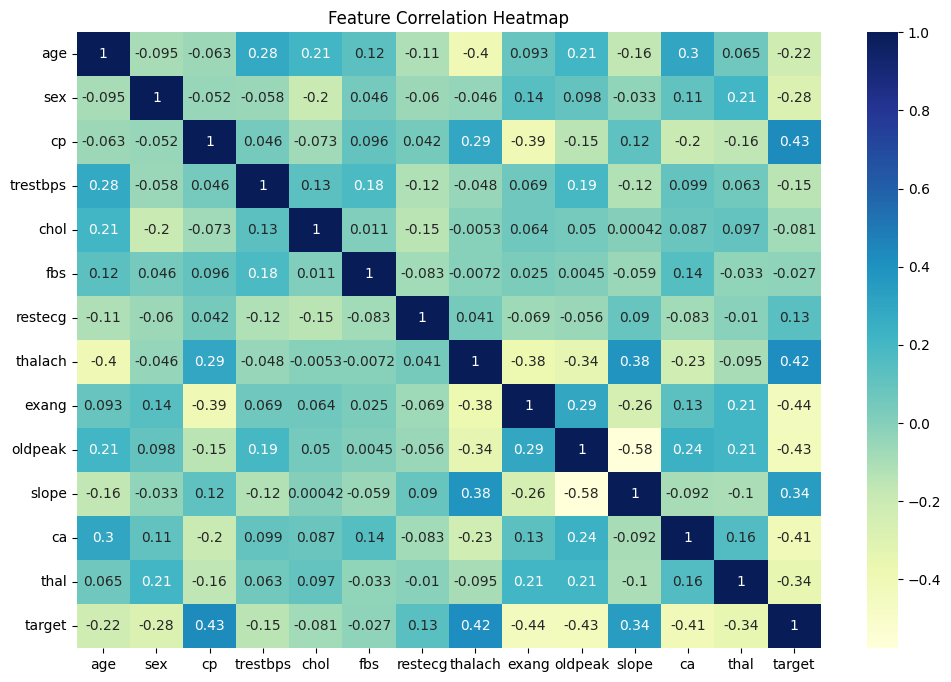

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Interpretation

Several variables show moderate relationships with the target variable, indicating their potential importance in predicting heart disease. Correlation analysis provides an initial understanding of feature relevance before model training.

In [18]:
from sklearn.ensemble import RandomForestClassifier

temp_model = RandomForestClassifier(
    random_state=42
)

temp_model.fit(X,y)

importance = pd.Series(
    temp_model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10)

,0
thalach,0.134202
cp,0.128033
oldpeak,0.115018
ca,0.108043
thal,0.099852
age,0.090054
chol,0.074063
trestbps,0.071019
exang,0.060830
slope,0.051134


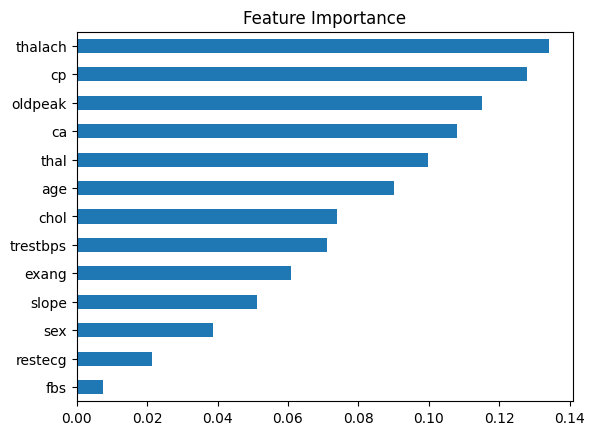

In [19]:
importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance")
plt.show()

### Interpretation

The feature importance analysis highlights the variables that contribute most to prediction performance. These features are likely to have the strongest influence on the presence of heart disease and can be prioritized in future model development.

## Model 1: Logistic Regression

Logistic Regression is a widely used classification algorithm that establishes a baseline for comparison. It performs well when relationships between features and the target variable are approximately linear.

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(X_test_scaled)

## Model 2: K Nearest Neighbors

K Nearest Neighbors classifies observations based on similarity to neighboring data points. Feature scaling is important because the algorithm relies on distance calculations.

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn.predict(X_test_scaled)

## Model 3: Random Forest Classifier

Random Forest is an ensemble learning technique that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [24]:
def evaluate_model(y_true, y_pred):

    return [
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred),
        recall_score(y_true,y_pred),
        f1_score(y_true,y_pred)
    ]

# Model Evaluation and Comparison

All models were evaluated using Accuracy, Precision, Recall, and F1 Score. These metrics provide a balanced assessment of classification performance.

In [26]:
results = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "KNN",
            "Random Forest"
        ],

        "Accuracy":[
            evaluate_model(y_test,lr_pred)[0],
            evaluate_model(y_test,knn_pred)[0],
            evaluate_model(y_test,rf_pred)[0]
        ],

        "Precision":[
            evaluate_model(y_test,lr_pred)[1],
            evaluate_model(y_test,knn_pred)[1],
            evaluate_model(y_test,rf_pred)[1]
        ],

        "Recall":[
            evaluate_model(y_test,lr_pred)[2],
            evaluate_model(y_test,knn_pred)[2],
            evaluate_model(y_test,rf_pred)[2]
        ],

        "F1 Score":[
            evaluate_model(y_test,lr_pred)[3],
            evaluate_model(y_test,knn_pred)[3],
            evaluate_model(y_test,rf_pred)[3]
        ]
    }
)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770492,0.702703,0.896552,0.787879
1,KNN,0.737705,0.696970,0.793103,0.741935
2,Random Forest,0.836066,0.787879,0.896552,0.838710


In [31]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.836066,0.787879,0.896552,0.838710
0,Logistic Regression,0.770492,0.702703,0.896552,0.787879
1,KNN,0.737705,0.696970,0.793103,0.741935


# Best Model Analysis

Based on the evaluation metrics, the best performing model was selected for further analysis. A confusion matrix was generated to understand prediction quality and classification behavior.

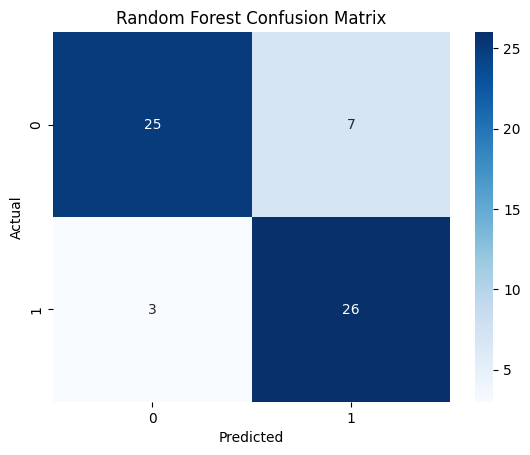

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

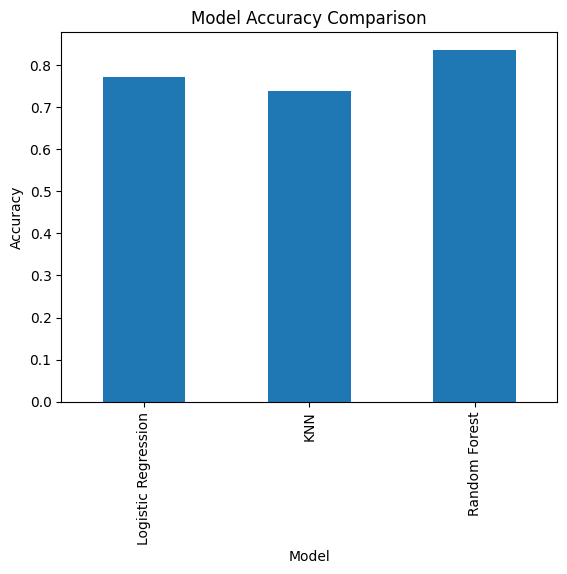

In [30]:
results.set_index("Model")["Accuracy"].plot(
    kind="bar"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Conclusion

This project developed and compared three machine learning models for heart disease prediction using patient health data. Logistic Regression, K Nearest Neighbors, and Random Forest were evaluated using multiple classification metrics. Among the tested algorithms, Random Forest achieved the strongest overall performance, demonstrating its ability to capture complex relationships within the dataset. Feature importance analysis identified the most influential predictors contributing to disease detection. The results suggest that machine learning can provide valuable support for healthcare decision making and early risk assessment.